Meeting: 12:30 Friday 2/10/26

Attendance:
Ben X
Tobias X

Recap:
We divided the project in two. Ben will look at stellar population and Tobias will look at dynamics.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib import rc
%matplotlib inline
rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
rc('text', usetex=True)

In [2]:
harris_p1 = pd.read_csv('HarrisPartI.csv')
harris_p2 = pd.read_csv('HarrisPartII.csv')
harris_p3 = pd.read_csv('HarrisPartIII.csv')

Stellar population analysis - Ben

Stellar dynamics analysis - Tobias

In [ ]:
R_gc = pd.to_numeric(harris_p1['R_gc'],errors='coerce')
R_Sun = pd.to_numeric(harris_p1['R_Sun'],errors='coerce')
sig_v = pd.to_numeric(harris_p3['sig_v'],errors='coerce')
v_r = pd.to_numeric(harris_p3['v_r'],errors='coerce')
mtlc = pd.to_numeric(harris_p2['[Fe/H]'],errors='coerce')

mask = mtlc > -0.8

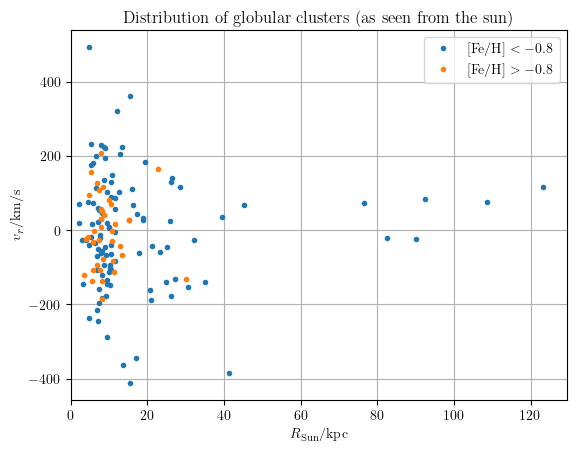

In [33]:
plt.figure()
plt.plot(R_Sun[~mask],v_r[~mask],'.',label=r'$[\mathrm{Fe/H}] < -0.8$')
plt.plot(R_Sun[mask],v_r[mask],'.',label=r'$[\mathrm{Fe/H}] > - 0.8$')
plt.legend()
plt.xlabel(r'$R_{\mathrm{Sun}}/\mathrm{kpc}$')
plt.ylabel(r'$v_r/\mathrm{km/s}$')
plt.grid()
plt.xlim(0)
plt.title(r'Distribution of globular clusters (as seen from the sun)')
plt.show()

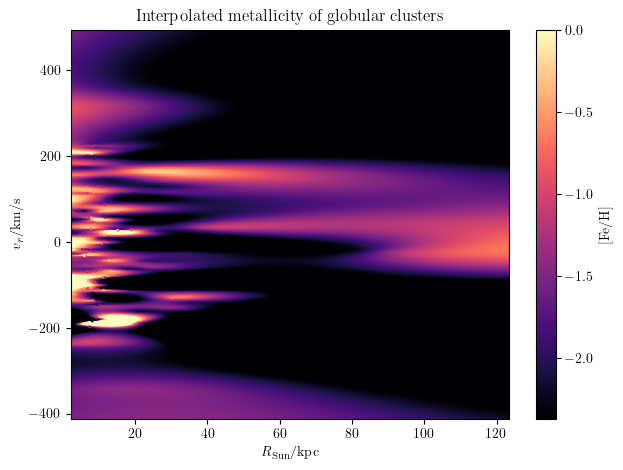

In [79]:
from scipy.interpolate import RBFInterpolator
RR = np.linspace(R_Sun.min(),R_Sun.max(),1000)
VV = np.linspace(v_r.min(),v_r.max(),1000)
RR,VV = np.meshgrid(RR,VV)
mask2 = np.isnan(R_Sun) | np.isnan(v_r) | np.isnan(mtlc)
R_array = R_Sun[~mask2]
V_array = v_r[~mask2]
M_array = mtlc[~mask2]
RV = np.transpose(np.array([R_array,V_array]))
rbf = RBFInterpolator(RV,M_array, kernel = 'thin_plate_spline')

# MM = griddata(RV,M_array,(RR,VV),method = 'cubic')
MM = rbf(np.column_stack((RR.ravel(), VV.ravel()))).reshape(RR.shape)



plt.figure()
Z_min,Z_max = mtlc.min(), mtlc.max()
plt.pcolormesh(RR,VV,MM,cmap='magma',vmin=Z_min,vmax=Z_max)
plt.scatter(R_Sun,v_r,1,mtlc,cmap='magma',vmin=Z_min,vmax=Z_max)
plt.colorbar(label =r'$[\mathrm{Fe/H}]$')
plt.xlabel(r'$R_{\mathrm{Sun}}/\mathrm{kpc}$')
plt.ylabel(r'$v_r/\mathrm{km/s}$')
plt.title(r'Interpolated metallicity of globular clusters')
plt.tight_layout()
plt.show()